### Exploratory Data Analysis

In [20]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno

DATA_FOLDER = "./data/"
OUTPUT_FOLDER = "./outputs/"
SEED = 404

warnings.filterwarnings('ignore')
%matplotlib inline

In [13]:
def apply_to_train_test(func):
    global train, test

    train, test = func(train), func(test)

In [14]:
def drop_columns(df: pd.DataFrame):
    return df.drop(columns=["Unnamed: 0", "Case_ID"])

def encode_y(df: pd.DataFrame):
    return df.replace({"GBM": 1, "LGG": 0})

In [15]:
train = pd.read_csv(DATA_FOLDER + "train.csv")
test = pd.read_csv(DATA_FOLDER + "test.csv")
apply_to_train_test(drop_columns)
train.head()

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,GBM,Male,79 years 183 days,Glioblastoma,black or african american,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,Male,53 years 197 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
2,LGG,Female,61 years 305 days,"Astrocytoma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,Female,58 years 55 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
4,LGG,Male,30 years 113 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


### Пропущенные значения

In [16]:
print(train.isna().sum())

Grade                0
Gender               0
Age_at_diagnosis     0
Primary_Diagnosis    0
Race                 0
IDH1                 0
TP53                 0
ATRX                 0
PTEN                 0
EGFR                 0
CIC                  0
MUC16                0
PIK3CA               0
NF1                  0
PIK3R1               0
FUBP1                0
RB1                  0
NOTCH1               0
BCOR                 0
CSMD3                0
SMARCA4              0
GRIN2A               0
IDH2                 0
FAT4                 0
PDGFRA               0
dtype: int64


Ни один из признаков не содержит пропущенных значений, однако возможны "заглушки" со стороны провайдера данных, например, указание прочерка, пробела или какого-то другого заменителя вместо явного `None`

In [17]:
print("Shape of train data", train.shape)
print("Number of duplicates", train.duplicated().sum())
print("Unique values of each column:", pd.DataFrame(train.nunique()).to_markdown(), sep="\n")

Shape of train data (603, 25)
Number of duplicates 0
Unique values of each column:
|                   |   0 |
|:------------------|----:|
| Grade             |   2 |
| Gender            |   3 |
| Age_at_diagnosis  | 595 |
| Primary_Diagnosis |   7 |
| Race              |   6 |
| IDH1              |   2 |
| TP53              |   2 |
| ATRX              |   2 |
| PTEN              |   2 |
| EGFR              |   2 |
| CIC               |   2 |
| MUC16             |   2 |
| PIK3CA            |   2 |
| NF1               |   2 |
| PIK3R1            |   2 |
| FUBP1             |   2 |
| RB1               |   2 |
| NOTCH1            |   2 |
| BCOR              |   2 |
| CSMD3             |   2 |
| SMARCA4           |   2 |
| GRIN2A            |   2 |
| IDH2              |   2 |
| FAT4              |   2 |
| PDGFRA            |   2 |


['black or african american' 'white' None 'asian'
 'american indian or alaska native']
['Male' 'Female' None]
['Glioblastoma' 'Astrocytoma, anaplastic' 'Astrocytoma, NOS'
 'Mixed glioma' 'Oligodendroglioma, anaplastic' 'Oligodendroglioma, NOS'
 None]


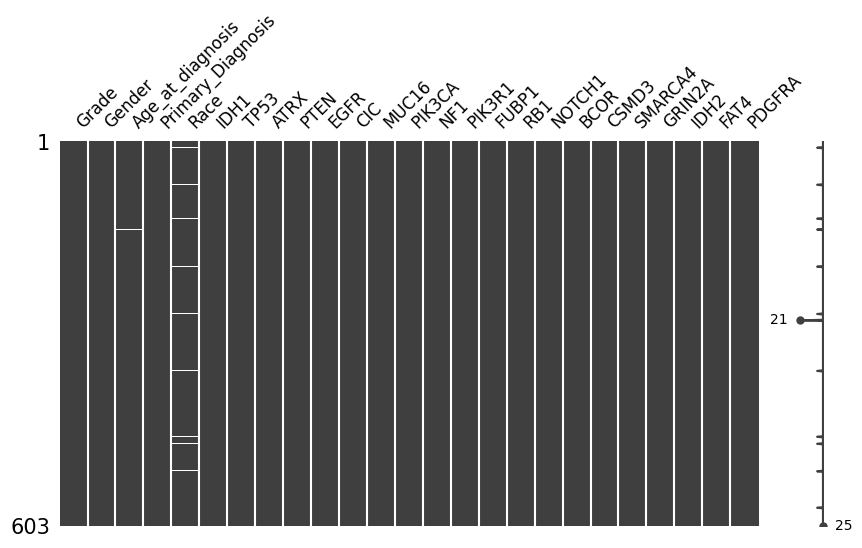

In [21]:
print(train["Race"].unique(), train["Gender"].unique(), train["Primary_Diagnosis"].unique(), sep="\n")

train = train.replace({"--": None, "not reported": None})

missingno.matrix(train, figsize=(10,5), fontsize=12);

Выходит, пропущенные значения все же есть, но их количество незначительно. Будем заменять их на медиану в численных признаках

In [41]:
def prepare_age(df: pd.DataFrame):
    df["Age_at_diagnosis"] = df["Age_at_diagnosis"].replace({"--": None, "not reported": None})
    df["Age_at_diagnosis"] = df["Age_at_diagnosis"].apply(lambda x: int(x.split(" ")[0]) if x else x)
    median = df["Age_at_diagnosis"].median(skipna=True)
    df["Age_at_diagnosis"] = df["Age_at_diagnosis"].fillna(int(median))
    return df

apply_to_train_test(prepare_age)
train.head(2)

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,GBM,Male,79.0,Glioblastoma,black or african american,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,Male,53.0,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED


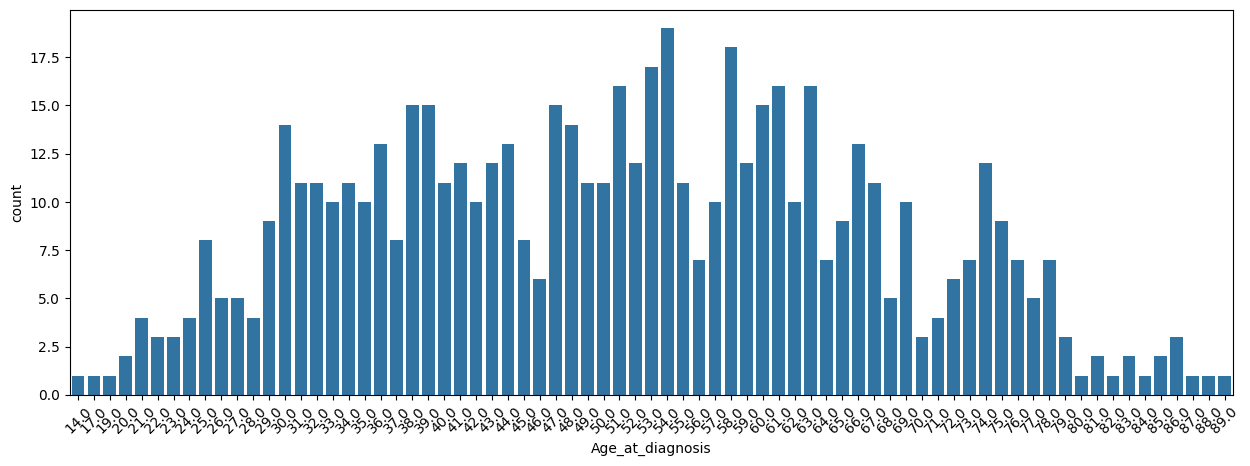

In [42]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train.sort_values(by="Age_at_diagnosis"), x="Age_at_diagnosis")
plt.xticks(rotation=45);

### Диагноз и целевая переменная

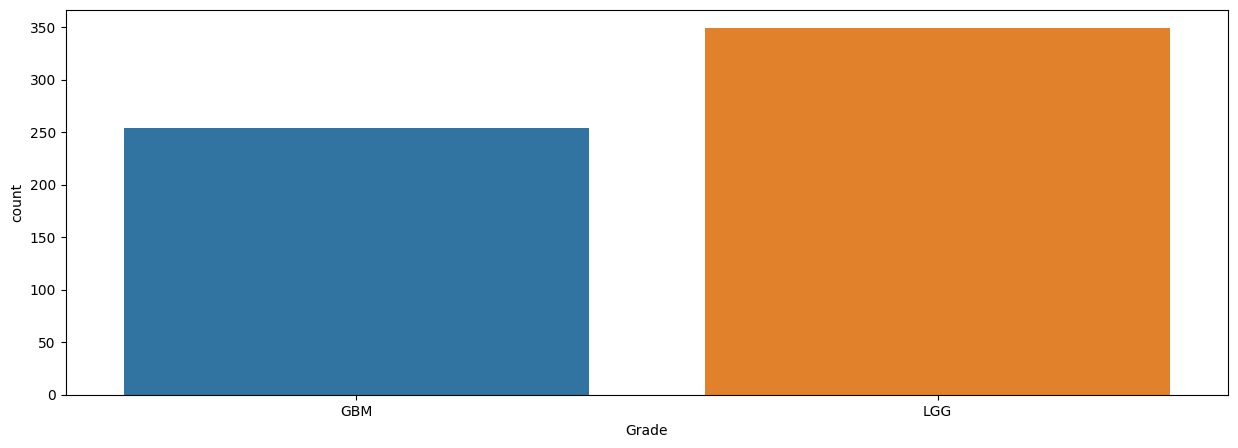

In [44]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train, x="Grade", hue="Grade");

Оба класса относительно неплохо сбалансированы, так что в целом каких-то методов аугментации не требуется, по крайней мере в контексте распределения целевого признака.

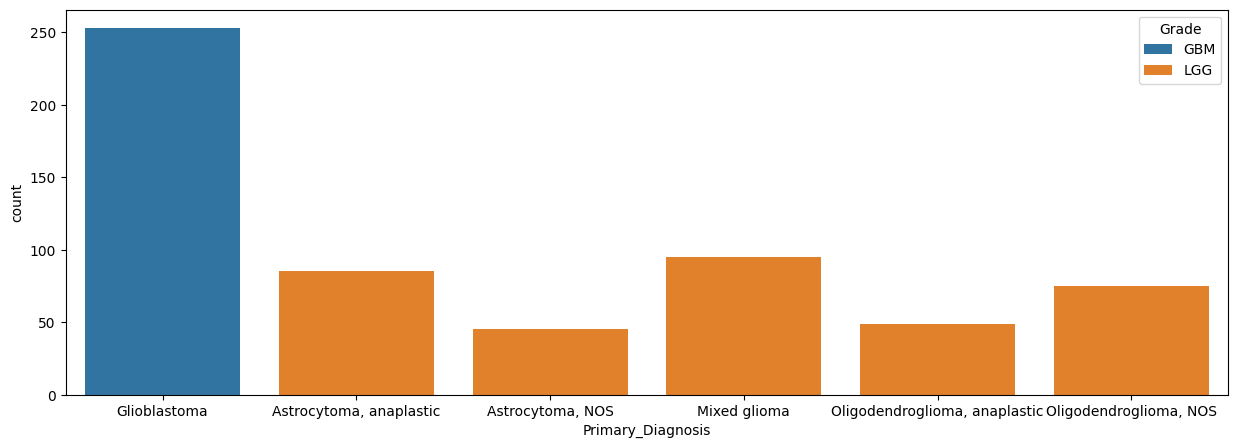

In [47]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train, x="Primary_Diagnosis", hue="Grade");

Amount of unknown data: 3


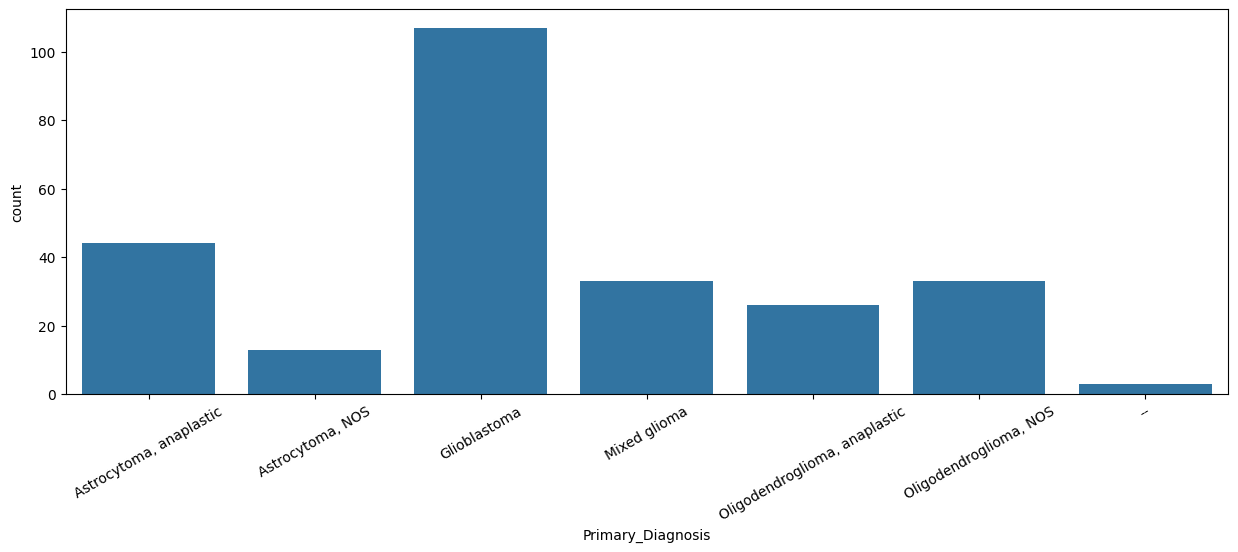

In [22]:
plt.figure(figsize=(15, 5))
plt.xticks(rotation=30)
sns.countplot(data=test, x="Primary_Diagnosis");
print("Amount of unknown data:", test[test["Primary_Diagnosis"] == "--"]["Primary_Diagnosis"].count())

### Зависимость типа опухоли от возраста

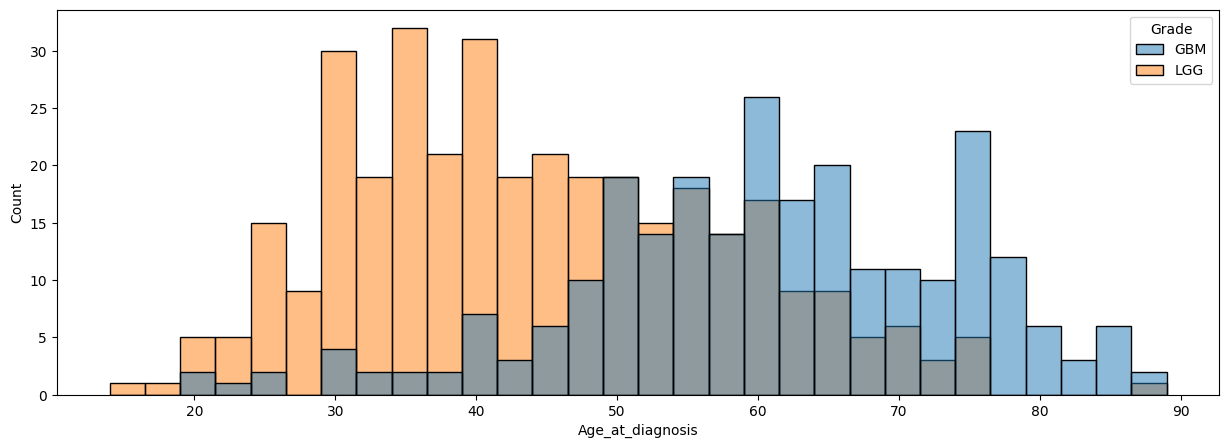

In [109]:
plt.figure(figsize=(15, 5))
sns.histplot(data=train, x="Age_at_diagnosis", hue="Grade", bins=30);

### Анализ мутаций генов

In [119]:
genes = list(train.drop(columns=["Grade", "Gender", "Age_at_diagnosis", "Primary_Diagnosis", "Race"]).columns)
assert len(genes) == 20

def get_mutated_features(row):
    mutated_features = []
    for feature in genes:
        if row[feature] == 'MUTATED':
            mutated_features.append(feature)
    return '_'.join(mutated_features) if mutated_features else 'NONE'

train["mutated_genes"] = train.apply(get_mutated_features, axis=1)

In [189]:
DROP_NUMBER = 1
cnt_mutated_genes = train.groupby(["mutated_genes", "Grade"])\
    .agg({"mutated_genes": "count"})\
    .rename(columns={"mutated_genes": "cnt"}).reset_index()
best_mutated_genes = cnt_mutated_genes[cnt_mutated_genes["cnt"] > DROP_NUMBER]

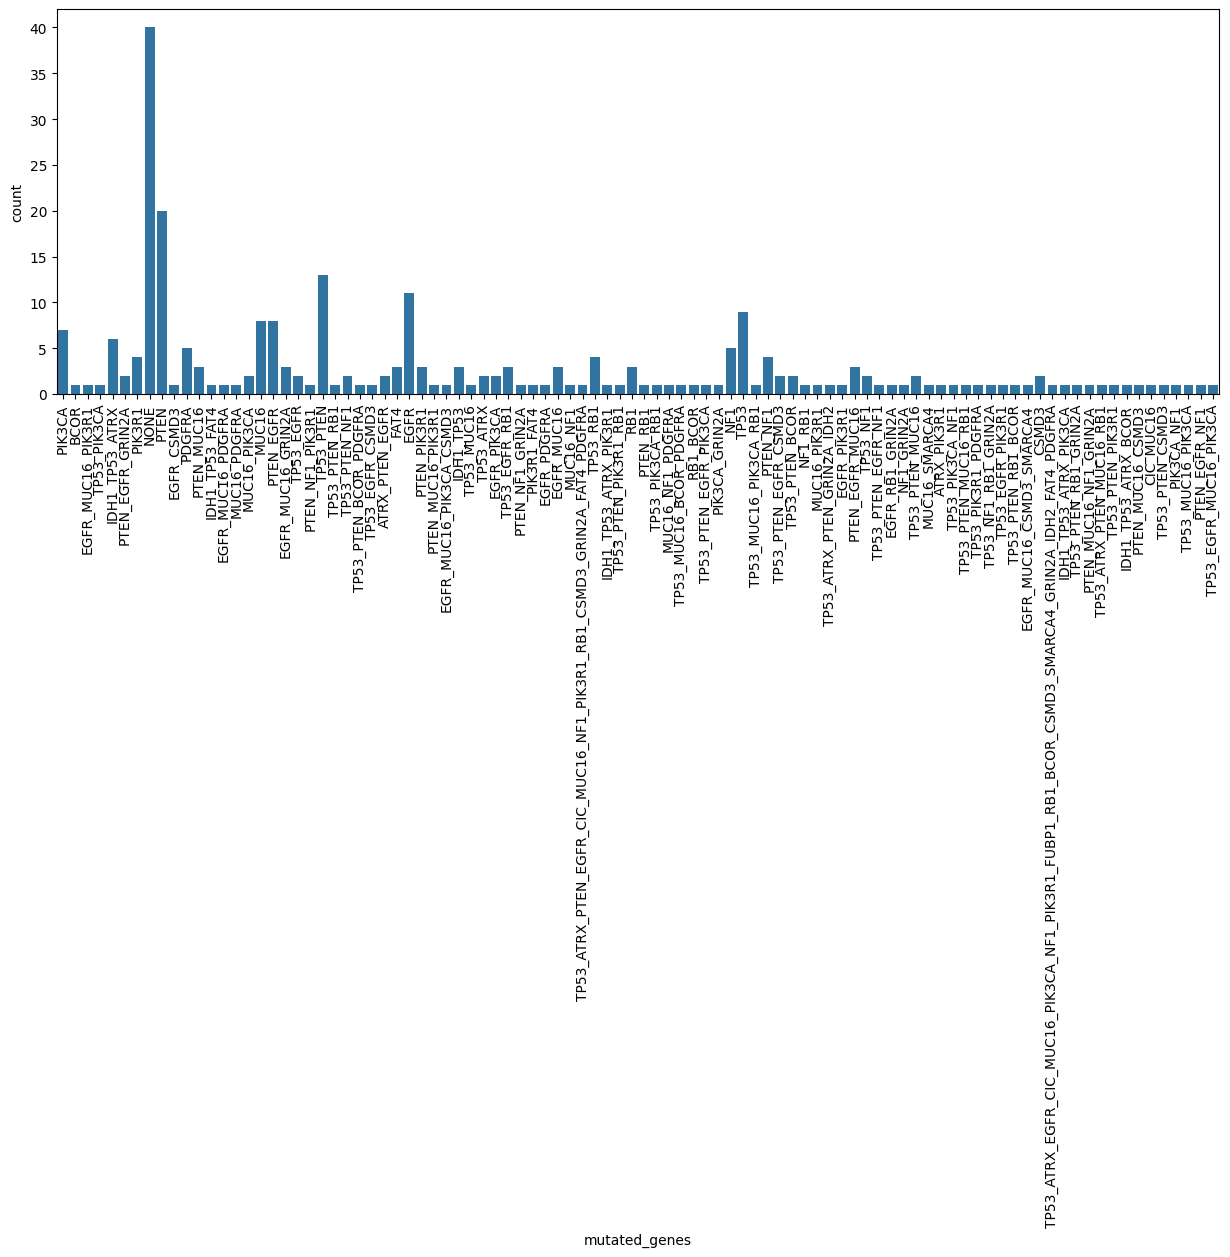

In [206]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train[train.Grade == "GBM"], x="mutated_genes");
plt.xticks(rotation=90);

TODO: Написать вывод

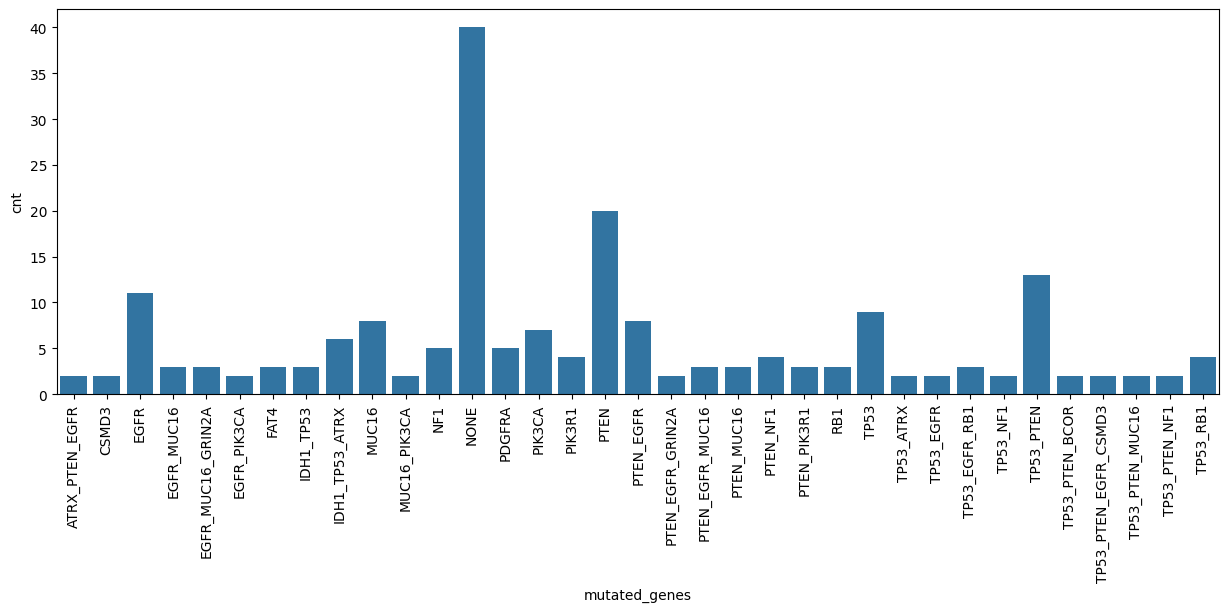

In [207]:
plt.figure(figsize=(15, 5))
sns.barplot(data=best_mutated_genes[best_mutated_genes["Grade"] == "GBM"], x="mutated_genes", y="cnt");
plt.xticks(rotation=90);

TODO: Написать вывод

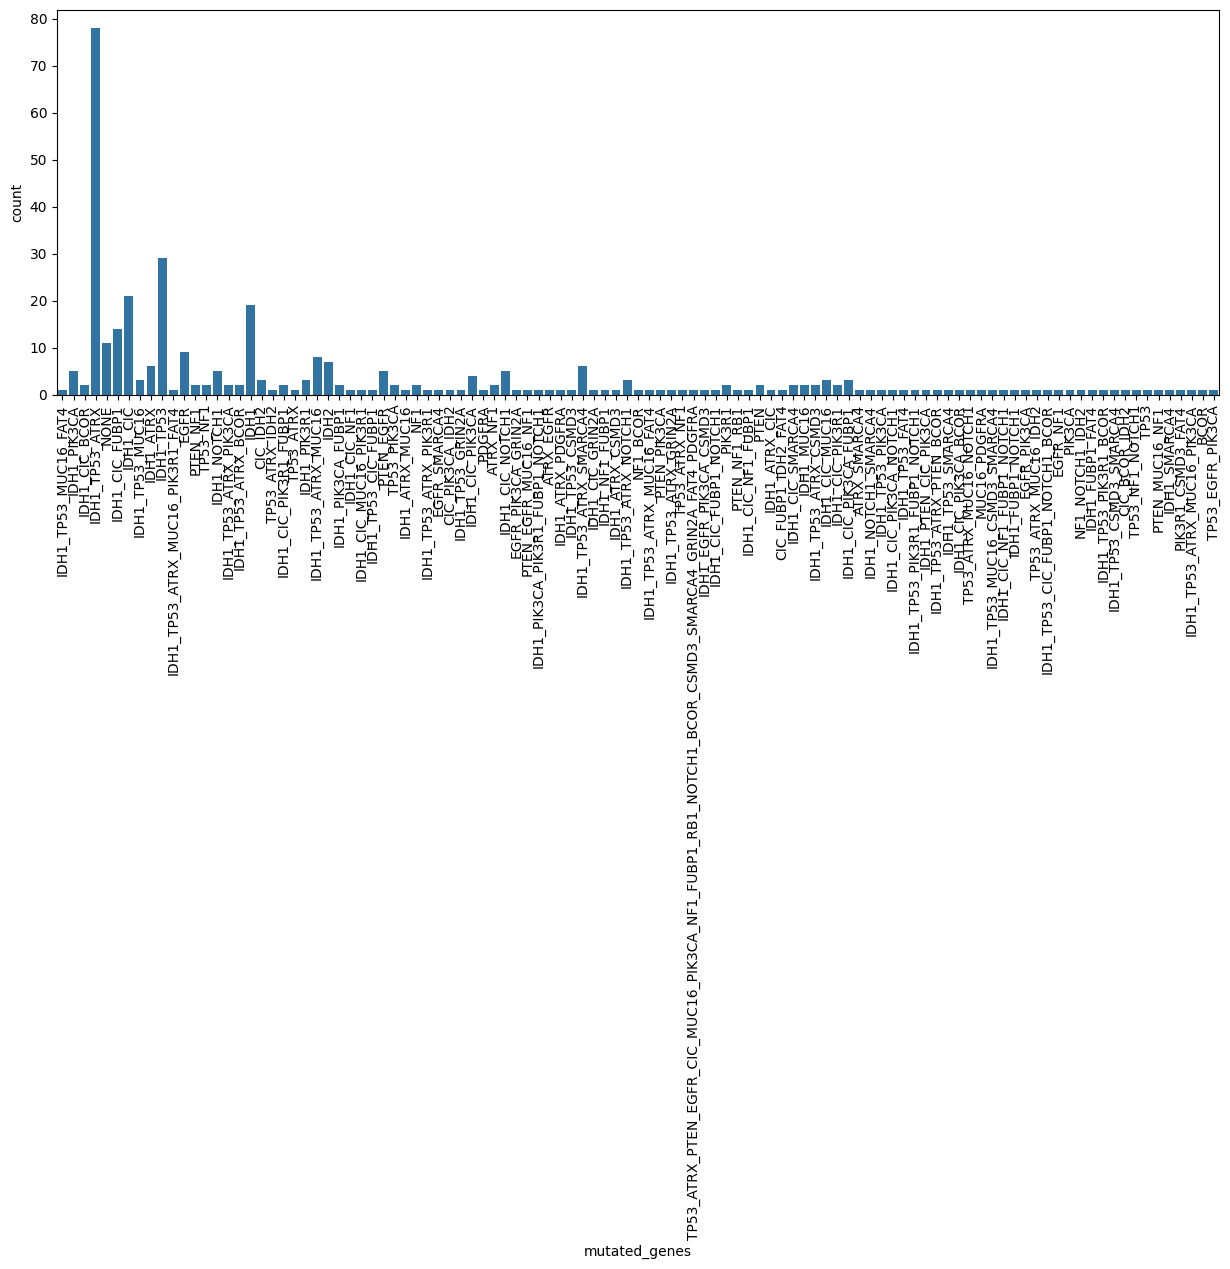

In [140]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train[train.Grade == "LGG"], x="mutated_genes");
plt.xticks(rotation=90);

TODO: Написать вывод

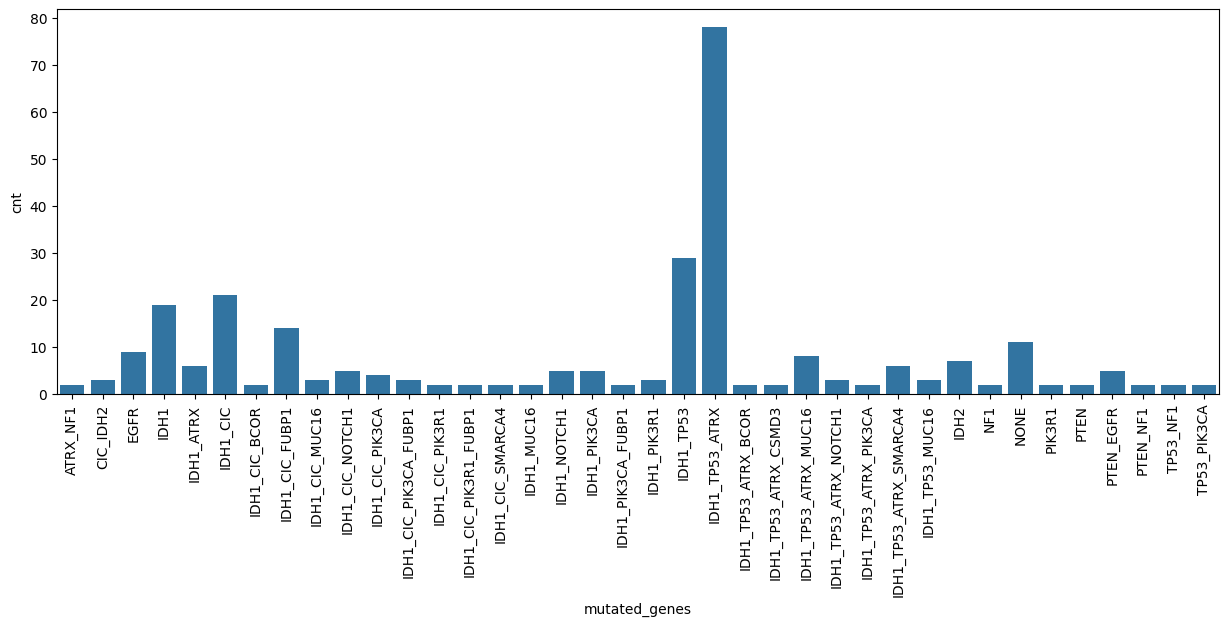

In [191]:
plt.figure(figsize=(15, 5))
sns.barplot(data=best_mutated_genes[best_mutated_genes["Grade"]=="LGG"], x="mutated_genes", y="cnt");
plt.xticks(rotation=90);

TODO: написать вывод

In [87]:
test[test["Primary_Diagnosis"] == "--"].drop(columns=["Gender", "Age_at_diagnosis", "Primary_Diagnosis", "Race"])

,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
20,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
56,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
187,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


In [209]:
test[test["Primary_Diagnosis"] == "--"].apply(get_mutated_features, axis=1)

20     IDH1_TP53_ATRX
56        EGFR_PIK3CA
187             MUC16
dtype: object